## **Seleção de Variáveis por Feature Importance**

A importância das variáveis (ou "feature importance") é frequentemente derivada de modelos específicos, e a formulação matemática para calcular essa importância pode variar dependendo do modelo. No contexto de modelos baseados em árvores, como Random Forest, a importância das variáveis é comumente calculada com base na impureza. Vamos explorar a formulação matemática para esse caso:

### **Feature Importance em Modelos Baseados em Árvores**

Considere uma árvore de decisão individual. A importância de uma variável é computada como:

$
\text{Importância}(X_j) = \sum_{\text{nós } t \text{ onde } X_j \text{ é usada}} \left( p(t) \times \text{Impureza}(t) \right) - p(\text{left}(t)) \times \text{Impureza}(\text{left}(t)) - p(\text{right}(t)) \times \text{Impureza}(\text{right}(t))
$

Onde:

- $ X_j $ é a j-ésima variável.
- O somatório é feito sobre todos os nós da árvore onde $ X_j $ é usada para dividir o nó.
- $ p(t) $ é a proporção de amostras que chegam ao nó $ t $.
- $ \text{Impureza}(t) $ é a medida de impureza no nó $ t $ (por exemplo, Gini impurity ou entropia para árvores de classificação).
- $ \text{left}(t) $ e $ \text{right}(t) $ são os subconjuntos de dados que são enviados para a esquerda e direita, respectivamente, quando o nó $ t $ é dividido usando $ X_j $.

Para uma **Random Forest**, a importância de cada variável é calculada como a média das importâncias da variável em todas as árvores na floresta.

### **Interpretação**:

- A importância calculada fornece uma pontuação para cada variável. Variáveis com maior pontuação são consideradas mais importantes.
- A importância é baseada na capacidade da variável de reduzir a impureza. Se uma variável consegue dividir os dados de uma forma que os subconjuntos resultantes são mais "puros" (ou seja, mais homogêneos em termos da variável resposta), essa variável é considerada importante.
- Essa técnica é "embutida" no sentido de que a importância é derivada diretamente da estrutura do modelo.

É importante notar que, enquanto a importância das variáveis nos dá uma ideia de quais variáveis têm o maior impacto no modelo, ela não nos dá uma indicação da relação entre a variável e a resposta (por exemplo, direção da relação).

In [9]:
#Mapear Drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [10]:
import pandas as pd

# Ler diretório Parquet
abt_00 = pd.read_csv('/content/gdrive/MyDrive/PoD Academy/Ciências de Dados/Aulas_EndToEnd_ModeloCredito/2.Aula009/abt_model.csv', engine='pyarrow')
abt_00.shape

(700, 23)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np

X = abt_00.drop(axis=1,columns='Churn')
y = abt_00.Churn

# Treinar modelo com algoritmo Random Forest (Calma, não precisa focar no modelo neste momento)
clf = RandomForestClassifier() # troque aqui qual classificador quer utilizar: GradientBoostingClassifier, DecisionTreeClassifier
clf.fit(X, y)

# Obter importância das variáveis
feature_importances = clf.feature_importances_
features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar variáveis por importância
features = features.sort_values(by='Importance', ascending=False)

# Estabelecer um limite de corte, por exemplo, x% da importância máxima
cutoff_maximp = 0.6

cutoff = cutoff_maximp * feature_importances.max()

# Selecionar variáveis acima do corte
selected_features = X.columns[feature_importances > cutoff].tolist()
selected_features


['Idade',
 'QT_DIAS_DESDE_INSCR',
 'VL_TOT_CONSUMO',
 'VL_MED_CONSUMO',
 'VL_MAX_CONSUMO',
 'VL_MIN_CONSUMO',
 'VL_TOT_CONS_ESPORTES',
 'VL_MED_CONS_ESPORTES',
 'VL_MED_CONS_Alimentos']

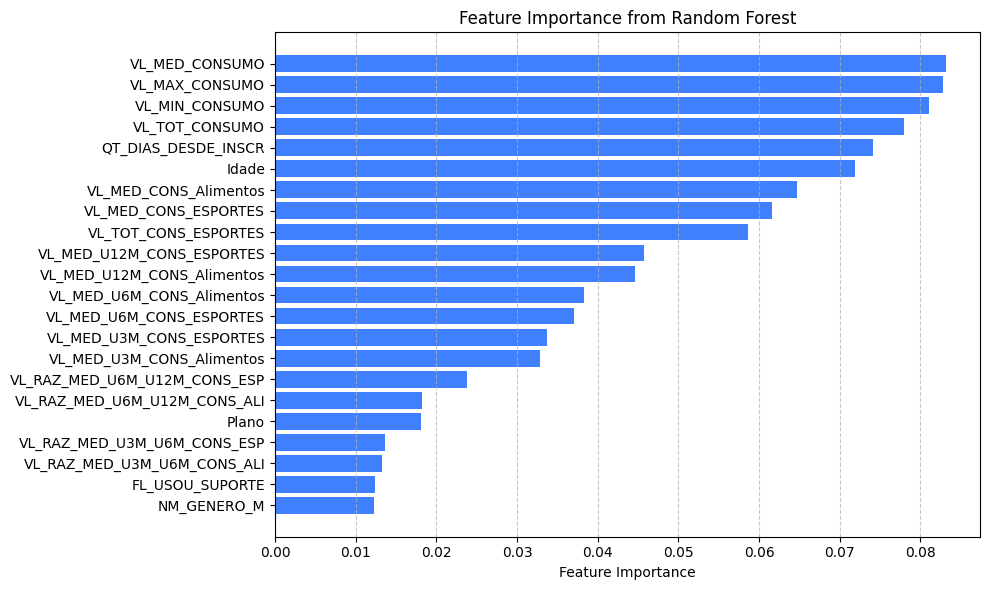

In [14]:
# Visualizando a importância das variáveis em barras horizontais
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sorted_idx = feature_importances.argsort()

plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx], color=(0.25, 0.5, 1))  # tom de azul claro
plt.xlabel("Feature Importance")
plt.title("Feature Importance from Random Forest")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
# Mantendo somente as variáveis selecionadas na ABT
abt_03 = abt_00[selected_features + ['Churn']]

abt_03.head()

,Idade,QT_DIAS_DESDE_INSCR,VL_TOT_CONSUMO,VL_MED_CONSUMO,VL_MAX_CONSUMO,VL_MIN_CONSUMO,VL_TOT_CONS_ESPORTES,VL_MED_CONS_ESPORTES,VL_MED_CONS_Alimentos,Churn
0,0.960784,0.547253,0.112101,0.736069,0.761995,0.728723,0.000000,0.497434,0.507888,0
1,0.725490,0.975824,0.393056,0.342307,0.945748,0.033548,0.016190,0.061085,0.715268,0
2,0.862745,0.945055,0.599184,0.320280,0.863192,0.055897,0.441229,0.373297,0.284370,0
3,0.882353,0.928022,0.163106,0.481587,0.672995,0.290994,0.000000,0.497434,0.507888,1
4,0.431373,0.256044,0.136081,0.386590,0.937637,0.020490,0.000000,0.497434,0.507888,1


## **Seleção de variáveis via Boruta**

O Boruta é um algoritmo de seleção de variáveis baseado em Random Forest. O objetivo do Boruta é encontrar e reter apenas as variáveis verdadeiramente importantes no conjunto de dados, enquanto remove aquelas que são apenas ruído.

O algoritmo funciona da seguinte forma:

1. **Duplicação e embaralhamento**: Para cada variável no conjunto de dados original, uma duplicata é criada e embaralhada. Estas são chamadas de variáveis "sombra".
2. **Treinamento (Random FOrest)**: Um modelo de floresta aleatória é treinado no conjunto de dados, que agora inclui as variáveis originais e suas sombras.
3. **Comparação de Importância**: A importância das variáveis originais é comparada com a importância das variáveis sombra. A ideia é que qualquer variável original que tenha importância significativamente maior do que a mais importante variável sombra é considerada relevante.
4. **Iteração**: O processo é repetido várias vezes, com as variáveis menos importantes sendo removidas em cada iteração, até que se tenha uma decisão clara sobre a relevância de cada variável.


In [16]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.5 MB/s eta 0:00:00


In [18]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Define o modelo - Random Forest
rf = RandomForestClassifier()

# Define o método Boruta
feat_selector = BorutaPy(
                         rf,
                         n_estimators='auto',
                         verbose=0,
                         random_state=1)

X = abt_00.drop(axis=1,columns='Churn')
y = abt_00.Churn

# Executa o Boruta
feat_selector.fit(X.values, y)

# Obtém as variáveis selecionadas
selected_features_boruta = X.columns[feat_selector.support_].tolist()
selected_features_boruta

[]

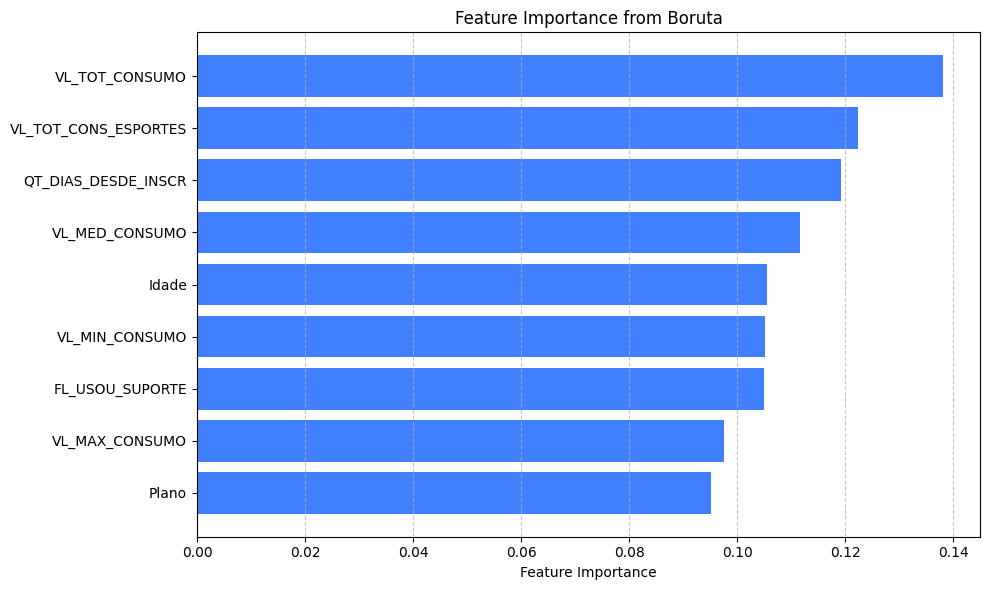

In [19]:
# Supondo que 'feat_selector' é sua instância BorutaPy e 'X' é seu DataFrame de características
importances = rf.feature_importances_
features = X.columns

# Ordenar as variáveis pela importância
sorted_idx = importances.argsort()

# Visualizar a importância das variáveis em barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx], color=(0.25, 0.5, 1))  # tom de azul claro
plt.xlabel("Feature Importance")
plt.title("Feature Importance from Boruta")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [20]:
# Mantendo somente as variáveis selecionadas na ABT
abt_04 = abt_00[selected_features_boruta + ['Churn']]

abt_04.head()

,Churn
0,0
1,0
2,0
3,1
4,1


## **Seleção de Variáveis por RFE**

A técnica de Eliminação Recursiva de Variáveis (Recursive Feature Elimination, RFE) é uma ótima abordagem para seleção de variáveis e é frequentemente usada em situações em que se deseja reduzir a dimensão do conjunto de dados mantendo as variáveis mais significativas.

### O que é RFE?

A Eliminação Recursiva de Variáveis (RFE) é uma técnica que seleciona variáveis de forma iterativa, treinando um modelo várias vezes. Em cada iteração, a variável considerada a "menos importante" é removida, reduzindo assim a dimensão do conjunto de dados.

### Como o RFE funciona?

1. Treine o modelo com todas as variáveis.
2. Avalie a importância de cada variável. Isso é geralmente feito com base em coeficientes (para modelos lineares) ou importância de variáveis (para modelos baseados em árvores).
3. Remova a variável menos importante.
4. Repita os passos 1-3 até que o número desejado de variáveis seja atingido ou até que se cumpra algum outro critério.

### Pontos relevantes a considerar sobre o RFE
- Modelo Base: O modelo base usado no RFE deve ser escolhido com cuidado. Nem todos os modelos são adequados para todas as situações.
- Custo Computacional: O RFE pode ser computacionalmente caro, especialmente com um grande número de variáveis, pois requer treinar o modelo várias vezes.





In [22]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Instancie o modelo (escolha um algoritmo desejado)
model = DecisionTreeClassifier()

# Instancie o RFE e selecione 2 variáveis
n_vars_keep = 2
X = abt_00.drop(axis=1,columns='Churn')
y = abt_00.Churn

# Instancie o RFE
rfe = RFE(estimator=model, n_features_to_select=n_vars_keep)
fit = rfe.fit(X, y)

selected_features_rfe = list(X.columns[fit.support_])
selected_features_rfe


['QT_DIAS_DESDE_INSCR', 'VL_MAX_CONSUMO']

In [23]:
# Mantendo somente as variáveis selecionadas na ABT
abt_05 = abt_00[selected_features_rfe + ['Churn']]

abt_05.head()

,QT_DIAS_DESDE_INSCR,VL_MAX_CONSUMO,Churn
0,0.547253,0.761995,0
1,0.975824,0.945748,0
2,0.945055,0.863192,0
3,0.928022,0.672995,1
4,0.256044,0.937637,1


## **Seleção de Variáveis por Information Value (Target Binário)**

O Valor de Informação (Information Value, IV) é uma métrica frequentemente usada em modelagem de crédito e outros domínios para avaliar a força preditiva de uma variável categórica em relação a uma variável alvo binária. Ele quantifica o quanto a presença (ou ausência) de uma categoria em particular de uma variável é útil para prever o resultado.

### Explicação:

O IV é calculado a partir do Peso da Evidência (Weight of Evidence, WoE) para cada categoria da variável. O WoE para uma categoria específica é o logaritmo da razão das proporções de eventos "bons" e "ruins" naquela categoria:

$
\text{WoE} = \ln\left(\frac{\text{Distr}_\text{Good}}{\text{Distr}_\text{Bad}}\right)
$

Onde:

- $\text{Distr}_\text{Good}$ é a proporção de eventos "bons" na categoria em relação a todos os eventos "bons".
- $\text{Distr}_\text{Bad}$ é a proporção de eventos "ruins" na categoria em relação a todos os eventos "ruins".

O IV para uma variável é a soma dos produtos da diferença entre $\text{Distr}_\text{Good}$ e $\text{Distr}_\text{Bad}$ pelo WoE, calculado para cada categoria da variável:

$
\text{IV} = \sum \left(\text{Distr}_\text{Good} - \text{Distr}_\text{Bad}\right) \times \text{WoE}
$

### Interpretação do IV:

A força preditiva de uma variável com base no seu IV pode ser interpretada da seguinte forma:

- Muito fraco: IV < 0.02
- Fraco: 0.02 <= IV < 0.1
- Moderado: 0.1 <= IV < 0.3
- Forte: 0.3 <= IV < 0.5
- Muito forte: IV >= 0.5

### Considerações:

- O IV é uma métrica univariada, o que significa que avalia a relação entre uma variável individual e a variável alvo, sem levar em consideração outras variáveis.
- O IV é mais apropriado para variáveis categóricas. Se você tem variáveis contínuas, elas devem ser discretizadas (por exemplo, em intervalos) antes de calcular o IV.
- Enquanto o IV fornece uma medida útil da força preditiva de uma variável, é importante também considerar outras informações e o contexto ao decidir incluir ou excluir uma variável de um modelo.

In [24]:
def discretize_numeric_features(df, bins):
    df_discretized = df.copy()
    for col in df.columns:
        if df[col].dtype in ['float64', 'float32', 'int64', 'int32'] and len(df[col].unique()) > bins:
            df_discretized[col] = pd.cut(df[col], bins=bins, labels=False, duplicates='drop')
    return df_discretized

def calculate_iv(df, feature, target):
    lst = []
    for value in df[feature].unique():
        lst.append({
            'Value': value,
            'All': df[df[feature] == value].count()[feature],
            'Good': df[(df[feature] == value) & (df[target] == 1)].count()[feature],
            'Bad': df[(df[feature] == value) & (df[target] == 0)].count()[feature]
        })

    dset = pd.DataFrame(lst)
    dset['Distr_Good'] = (dset['Good'] + 0.0001) / (dset['Good'].sum() + 0.0001)  # Adding a small value to avoid division by zero
    dset['Distr_Bad'] = (dset['Bad'] + 0.0001) / (dset['Bad'].sum() + 0.0001)  # Adding a small value to avoid division by zero
    dset['WoE'] = np.log(dset['Distr_Good'] / dset['Distr_Bad']).replace({np.inf: 0, -np.inf: 0})
    dset['IV'] = (dset['Distr_Good'] - dset['Distr_Bad']) * dset['WoE']
    return dset['IV'].sum()

def classify_iv(iv_value):
    if iv_value < 0.02:
        return "Muito Fraco"
    elif iv_value < 0.1:
        return "Fraco"
    elif iv_value < 0.3:
        return "Moderado"
    elif iv_value < 0.5:
        return "Forte"
    else:
        return "Muito Forte"

# def select_features_by_iv_with_progress(df, target, iv_cutoff_ratio=1.0):
#     from tqdm import tqdm
#     iv_stats = []
#     for col in tqdm(df.columns, desc="Calculating IV", unit="variable"):
#         if col != target:
#             iv_value = calculate_iv(df, col, target)
#             iv_stats.append({
#                 'Variable': col,
#                 'IV': iv_value,
#                 'Predictiveness': classify_iv(iv_value)
#             })

#     iv_df = pd.DataFrame(iv_stats).sort_values(by='IV', ascending=False)
#     max_iv = iv_df['IV'].max()
#     cutoff_value = iv_cutoff_ratio * max_iv
#     selected_features = iv_df[iv_df['IV'] >= cutoff_value]['Variable'].tolist()

#     return selected_features, iv_df

def select_features_by_iv_discretized(df, target, iv_cutoff_ratio=1.0, bins=10):
    from tqdm import tqdm
    df = discretize_numeric_features(df, bins)

    iv_stats = []
    for col in tqdm(df.columns, desc="Calculating IV", unit="variable"):
        if col != target:
            iv_value = calculate_iv(df, col, target)
            iv_stats.append({
                'Variable': col,
                'IV': iv_value,
                'Predictiveness': classify_iv(iv_value)
            })

    iv_df = pd.DataFrame(iv_stats).sort_values(by='IV', ascending=False)
    max_iv = iv_df['IV'].max()
    cutoff_value = iv_cutoff_ratio * max_iv
    selected_features = iv_df[iv_df['IV'] >= cutoff_value]['Variable'].tolist()

    return selected_features, iv_df

In [25]:
# Testing the function using a binarized version of the iris dataset
selected_vars_iv, iv_data = select_features_by_iv_discretized(abt_00, 'Churn', iv_cutoff_ratio=0.25, bins=10)
selected_vars_iv

Calculating IV: 100%|██████████| 23/23 [00:02<00:00,  8.44variable/s]


['VL_RAZ_MED_U3M_U6M_CONS_ALI',
 'VL_RAZ_MED_U6M_U12M_CONS_ESP',
 'VL_RAZ_MED_U6M_U12M_CONS_ALI',
 'VL_RAZ_MED_U3M_U6M_CONS_ESP',
 'VL_MIN_CONSUMO',
 'VL_TOT_CONS_ESPORTES',
 'VL_MED_U6M_CONS_ESPORTES',
 'VL_MED_U3M_CONS_Alimentos',
 'VL_MAX_CONSUMO']

In [26]:
iv_data

,Variable,IV,Predictiveness
19,VL_RAZ_MED_U3M_U6M_CONS_ALI,0.219944,Moderado
18,VL_RAZ_MED_U6M_U12M_CONS_ESP,0.178457,Moderado
20,VL_RAZ_MED_U6M_U12M_CONS_ALI,0.142899,Moderado
17,VL_RAZ_MED_U3M_U6M_CONS_ESP,0.084891,Fraco
7,VL_MIN_CONSUMO,0.078712,Fraco
8,VL_TOT_CONS_ESPORTES,0.078248,Fraco
11,VL_MED_U6M_CONS_ESPORTES,0.075444,Fraco
14,VL_MED_U3M_CONS_Alimentos,0.058214,Fraco
6,VL_MAX_CONSUMO,0.055655,Fraco
12,VL_MED_U12M_CONS_ESPORTES,0.054399,Fraco


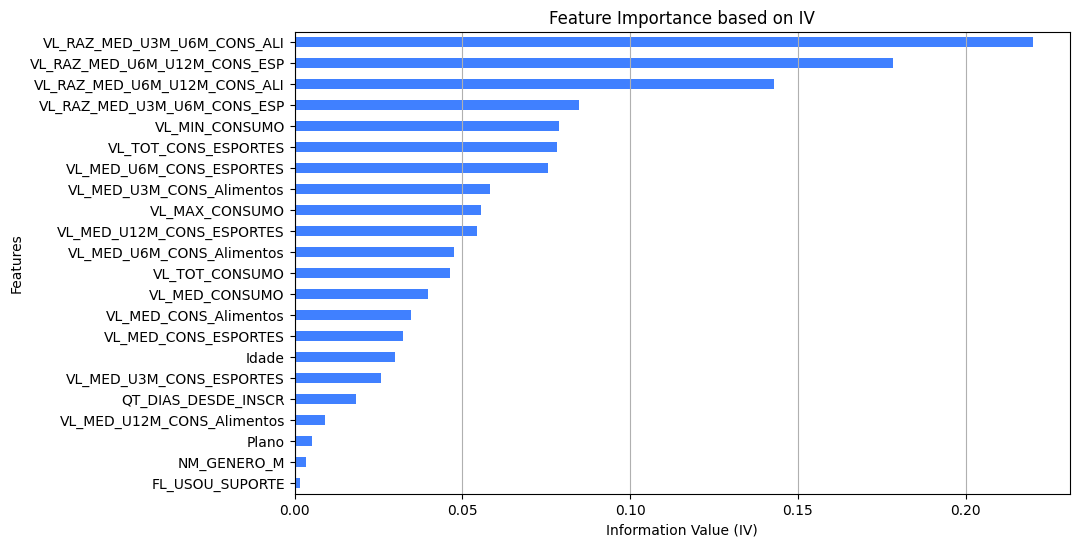

In [27]:
import matplotlib.pyplot as plt

def plot_iv(df_iv_data):
    plt.figure(figsize=(10, 6))
    df_iv_data.sort_values('IV').set_index('Variable')['IV'].plot(kind='barh', color=(0.25, 0.5, 1))
    plt.xlabel('Information Value (IV)')
    plt.ylabel('Features')
    plt.title('Feature Importance based on IV')
    plt.grid(axis='x')
    plt.show()

plot_iv(iv_data)


In [28]:
# Mantendo somente as variáveis selecionadas na ABT
abt_06 = abt_00[selected_vars_iv + ['Churn']]

abt_06.head()

,VL_RAZ_MED_U3M_U6M_CONS_ALI,VL_RAZ_MED_U6M_U12M_CONS_ESP,VL_RAZ_MED_U6M_U12M_CONS_ALI,VL_RAZ_MED_U3M_U6M_CONS_ESP,VL_MIN_CONSUMO,VL_TOT_CONS_ESPORTES,VL_MED_U6M_CONS_ESPORTES,VL_MED_U3M_CONS_Alimentos,VL_MAX_CONSUMO,Churn
0,0.459772,0.491668,0.442089,0.419268,0.728723,0.000000,0.506475,0.512698,0.761995,0
1,0.460993,0.491668,0.441624,0.419268,0.033548,0.016190,0.506475,0.953799,0.945748,0
2,0.459772,0.491018,0.442089,0.415584,0.055897,0.441229,0.158379,0.512698,0.863192,0
3,0.459772,0.491668,0.442089,0.419268,0.290994,0.000000,0.506475,0.512698,0.672995,1
4,0.459772,0.491668,0.442089,0.419268,0.020490,0.000000,0.506475,0.512698,0.937637,1
